In [54]:
import time
import numpy as np
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns


In [55]:
# Download stopwords if not already done
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [56]:
# Load dataset
df = pd.read_csv(r'reviews.csv')

In [57]:
# Top 5 Records in dataset
df.head(5)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [58]:
# Preprocess the text data by (Tokenization, Stop words, Stemming)
# Clean the text, convert to lowercase, remove non-alphabet characters, tokenize, apply stemming, and remove stopwords
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabet characters
    tokens = word_tokenize(text)  # Tokenize text into words
    stop_words = set(stopwords.words('english'))  # Set of English stopwords
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    stemmer = PorterStemmer()  # Initialize the Porter Stemmer
    tokens = [stemmer.stem(word) for word in tokens]  # Apply stemming
    return ' '.join(tokens)  # Join tokens back into a string

In [59]:
# New Coloumn in dataset that store processed dataset
df['processed_text'] = df['text'].apply(preprocess_text)  # Applying preprocessing to the reviews

In [25]:
# Records in dataset
df.head(5)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,processed_text
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,decid eat awar go take hour begin end tri mult...
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,ive taken lot spin class year noth compar clas...
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,famili diner buffet eclect assort larg chicken...
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,wow yummi differ delici favorit lamb curri kor...
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,cute interior owner gave us tour upcom patioro...


In [26]:
# Showing original text, processed text
df[['text', 'processed_text']]

,text,processed_text
0,"If you decide to eat here, just be aware it is...",decid eat awar go take hour begin end tri mult...
1,I've taken a lot of spin classes over the year...,ive taken lot spin class year noth compar clas...
2,Family diner. Had the buffet. Eclectic assortm...,famili diner buffet eclect assort larg chicken...
3,"Wow! Yummy, different, delicious. Our favo...",wow yummi differ delici favorit lamb curri kor...
4,Cute interior and owner (?) gave us tour of up...,cute interior owner gave us tour upcom patioro...
...,...,...
99995,Came here for lunch with a group. They were bu...,came lunch group busi still room us servic goo...
99996,The equipment is so old and so felty! I just u...,equip old felti upgrad multi club membership c...
99997,This is one of my favorite Mexican restaurants...,one favorit mexican restaur authent menu typic...
99998,Came here for brunch - had an omlette ($19 + t...,came brunch omlett tax tip food wayyyyyyy over...


In [27]:
# Label encoding (Positive, Negative)
# We label 'Negative' for <= 2 stars, 'Positive' for 4 or 5 stars, 'Neutral' for 3 stars
def encode_labels(stars):
    if stars <= 2:
        return 'Negative'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Positive'

In [28]:
# New Column in dataset to Store lablel's
df['label'] = df['stars'].apply(encode_labels)  # Apply the label encoding function

In [29]:
# show dataset
df[['stars', 'label', 'text', 'processed_text']]

,stars,label,text,processed_text
0,3,Neutral,"If you decide to eat here, just be aware it is...",decid eat awar go take hour begin end tri mult...
1,5,Positive,I've taken a lot of spin classes over the year...,ive taken lot spin class year noth compar clas...
2,3,Neutral,Family diner. Had the buffet. Eclectic assortm...,famili diner buffet eclect assort larg chicken...
3,5,Positive,"Wow! Yummy, different, delicious. Our favo...",wow yummi differ delici favorit lamb curri kor...
4,4,Positive,Cute interior and owner (?) gave us tour of up...,cute interior owner gave us tour upcom patioro...
...,...,...,...,...
99995,4,Positive,Came here for lunch with a group. They were bu...,came lunch group busi still room us servic goo...
99996,1,Negative,The equipment is so old and so felty! I just u...,equip old felti upgrad multi club membership c...
99997,4,Positive,This is one of my favorite Mexican restaurants...,one favorit mexican restaur authent menu typic...
99998,2,Negative,Came here for brunch - had an omlette ($19 + t...,came brunch omlett tax tip food wayyyyyyy over...


In [30]:
# Split the data into train and test sets (80% train, 20% test)
x = df['processed_text']
y = df['label']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
# Shape of train data set
print('x_train shape : ', x_train.shape)
print('y_train shape : ', y_train.shape)

x_train shape :  (80000,)
y_train shape :  (80000,)


In [32]:
# Shape of test data set
print('x_test shape : ', x_test.shape)
print('y_test shape : ', y_test.shape)

x_test shape :  (20000,)
y_test shape :  (20000,)


In [33]:
# Shape of test data set
print('x_test shape : ', x_test.shape)
print('y_test shape : ', y_test.shape)

x_test shape :  (20000,)
y_test shape :  (20000,)


In [39]:
# Required Libraries
from sklearn.svm import LinearSVC  # Ensure this is imported
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
# Import the classification_report function
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords  # Import stopwords
from nltk.stem import PorterStemmer
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

--- Training SVM Model (Unigram) ---



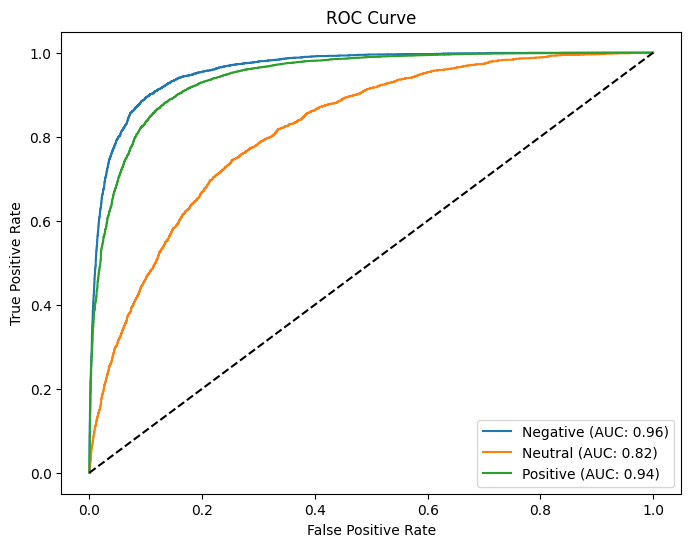

Training Time: 4.48 seconds
Training Accuracy: 0.8602875
Testing Accuracy: 0.8485

Training Confusion Matrix:
 [[12650   598  1899]
 [ 2157  2110  4820]
 [ 1080   623 54063]]
Testing Confusion Matrix:
 [[ 3053   164   545]
 [  583   458  1234]
 [  328   176 13459]]

F1 Scores for Test Data:
F1 Score for Positive: 0.9218177459676038
F1 Score for Negative: 0.7903184053844162
F1 Score for Neutral: 0.29808005206638466

Cross-Validation Accuracy Scores: [0.8448125 0.8485625 0.84275   0.8458125 0.848375 ]
Mean Cross-Validation Accuracy: 0.8460625

Top 10 Features with Highest Weights (per class):
Negative: ['worst', 'horribl', 'disgust', 'terribl', 'aw', 'tasteless', 'rude', 'bland', 'poorli', 'wors']
Neutral: ['alright', 'ok', 'okay', 'howev', 'averag', 'decent', 'noth', 'though', 'potenti', 'wasnt']
Positive: ['amaz', 'delici', 'great', 'awesom', 'perfect', 'excel', 'fantast', 'love', 'best', 'favorit']

--------------------------------------------------

--- Training SVM Model (Bigram) --

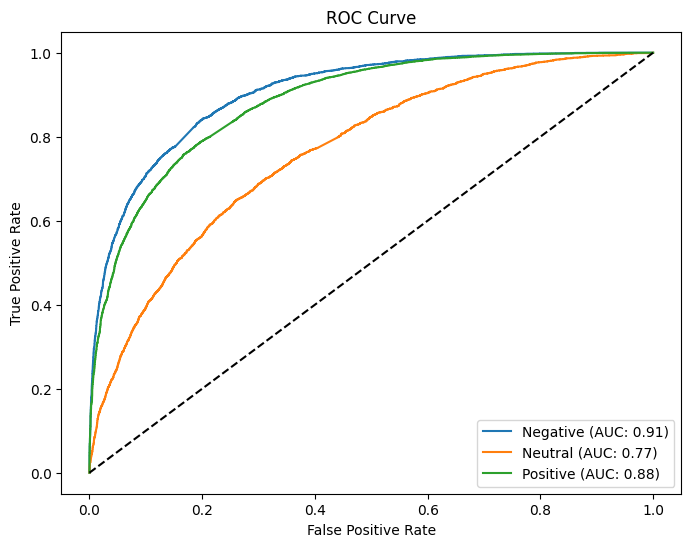

Training Time: 1.01 seconds
Training Accuracy: 0.806075
Testing Accuracy: 0.79725

Training Confusion Matrix:
 [[ 9616   379  5152]
 [ 1786  1205  6096]
 [ 1723   378 53665]]
Testing Confusion Matrix:
 [[ 2325   100  1337]
 [  510   268  1497]
 [  488   123 13352]]

F1 Scores for Test Data:
F1 Score for Positive: 0.8857341868718697
F1 Score for Negative: 0.6563161609033169
F1 Score for Neutral: 0.19378163412870572

Cross-Validation Accuracy Scores: [0.7973125 0.7906875 0.7930625 0.7943125 0.7925625]
Mean Cross-Validation Accuracy: 0.7935874999999999

Top 10 Features with Highest Weights (per class):
Negative: ['two star', 'zero star', 'wast money', 'never return', 'one worst', 'never come', 'wont back', 'wont return', 'worst experi', 'horribl servic']
Neutral: ['three star', 'decent food', 'give anoth', 'food decent', 'food ok', 'probabl go', 'food averag', 'food okay', 'wasnt bad', 'part meal']
Positive: ['hand best', 'everyth delici', 'definit back', 'highli recommend', 'exceed expec

In [53]:
def train_and_evaluate_svm(x_train, x_test, y_train, y_test, ngram_range, label):
    print(f"--- Training SVM Model ({label}) ---\n")

    # TF-IDF Vectorization
    tfidf_vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=2000)
    x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
    x_test_tfidf = tfidf_vectorizer.transform(x_test)

    # Train the SVM Model
    svm_model = LinearSVC(random_state=42)
    start_time = time.time()
    svm_model.fit(x_train_tfidf, y_train)
    train_time = time.time() - start_time

    # Predictions
    y_train_pred = svm_model.predict(x_train_tfidf)
    y_test_pred = svm_model.predict(x_test_tfidf)

    # Evaluate the Model
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_conf_matrix = confusion_matrix(y_train, y_train_pred)
    test_conf_matrix = confusion_matrix(y_test, y_test_pred)
    f1_test_report = classification_report(y_test, y_test_pred, output_dict=True)

    # Cross Validation
    cross_val_scores = cross_val_score(svm_model, x_train_tfidf, y_train, cv=5, scoring='accuracy')

    # Feature Analysis
    top_features = {}
    try:
        class_names = svm_model.classes_  # Get class names
        for i, class_label in enumerate(class_names):
            # Sort feature weights for the class
            feature_weights = svm_model.coef_[i]
            top_features_idx = np.argsort(feature_weights)[::-1][:10]  # Top 10 features
            top_features[class_label] = [tfidf_vectorizer.get_feature_names_out()[idx] for idx in top_features_idx]
    except:
        print("Feature weight analysis is not applicable for the model.")

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    try:
        y_test_prob = svm_model.decision_function(x_test_tfidf)
        for i, class_label in enumerate(svm_model.classes_):
            fpr, tpr, _ = roc_curve(pd.get_dummies(y_test)[class_label], y_test_prob[:, i])
            auc_score = roc_auc_score(pd.get_dummies(y_test)[class_label], y_test_prob[:, i])
            plt.plot(fpr, tpr, label=f"{class_label} (AUC: {auc_score:.2f})")
    except:
        print("ROC Curve cannot be plotted for this LinearSVC.")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    # Print Results
    print(f"Training Time: {train_time:.2f} seconds")
    print("Training Accuracy:", train_accuracy)
    print("Testing Accuracy:", test_accuracy)
    print("\nTraining Confusion Matrix:\n", train_conf_matrix)
    print("Testing Confusion Matrix:\n", test_conf_matrix)
    print("\nF1 Scores for Test Data:")
    print("F1 Score for Positive:", f1_test_report.get("Positive", {}).get("f1-score", "N/A"))
    print("F1 Score for Negative:", f1_test_report.get("Negative", {}).get("f1-score", "N/A"))
    print("F1 Score for Neutral:", f1_test_report.get("Neutral", {}).get("f1-score", "N/A"))
    print("\nCross-Validation Accuracy Scores:", cross_val_scores)
    print("Mean Cross-Validation Accuracy:", cross_val_scores.mean())
    print("\nTop 10 Features with Highest Weights (per class):")
    for class_label, features in top_features.items():
        print(f"{class_label}: {features}")
    print("\n" + "-" * 50 + "\n")

# Call the function for Unigram
train_and_evaluate_svm(x_train, x_test, y_train, y_test, ngram_range=(1, 1), label="Unigram")

# Call the function for Bigram
train_and_evaluate_svm(x_train, x_test, y_train, y_test, ngram_range=(2, 2), label="Bigram")
